In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Detecting encoding of dataset

In [2]:
import chardet
path="/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv"
with open(path, "rb") as f:
    result=chardet.detect(f.read())
print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [3]:
df=pd.read_csv("/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv", encoding="cp1252")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.duplicated().sum()

np.int64(0)

> The dataset has no duplicate rows, no missing values

## correcting date format and adding some features

In [7]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])
df["Order Month"]=df["Order Date"].dt.month
df["Ship Month"]=df["Ship Date"].dt.month
df["Order Year"]=df["Order Date"].dt.year
df["Ship Year"]=df["Ship Date"].dt.year

In [8]:
len(df[df["Order Date"].dt.month == 1].index)

381

In [9]:
overall_month_sales=pd.DataFrame(columns=["Month", "Number of sales", "Total sales", "Total profit"])

In [10]:
overall_month_sales= df.groupby("Order Month", sort=True).agg(
    Number_of_sales=("Sales","count"),
    Total_sales=("Sales","sum"),
    Total_profit=("Profit","sum")
).reset_index()
overall_month_sales.rename(columns={"Order Month": "Month"}, inplace=True)
overall_month_sales["Month"]=pd.to_datetime(overall_month_sales["Month"],format="%m").dt.month_name()
overall_month_sales

,Month,Number_of_sales,Total_sales,Total_profit
0,January,381,94924.8356,9134.4461
1,February,300,59751.2514,10294.6107
2,March,696,205005.4888,28594.6872
3,April,668,137762.1286,11587.4363
4,May,735,155028.8117,22411.3078
5,June,717,152718.6793,21285.7954
6,July,710,147238.0970,13832.6648
7,August,706,159044.0630,21776.9384
8,September,1383,307649.9457,36857.4753
9,October,819,200322.9847,31784.0413


## Finding KPI's

In [11]:
total_sale=overall_month_sales["Total_sales"].sum()
total_profit=overall_month_sales["Total_profit"].sum()
total_uni_orders=df["Order ID"].nunique()
avg_order_val=total_sale/total_uni_orders
profit_margin=(total_profit/total_sale)*100

In [12]:
total_sale

np.float64(2297200.8603)

### Finding:
- Best-performing and
- Loss-making

In [13]:
cat_sales=df.groupby("Category")[["Sales","Profit"]].sum().reset_index()
sub_cat_sales=df.groupby(["Category", "Sub-Category"])[["Sales","Profit"]].sum().reset_index()
region_sales=df.groupby("Region")[["Sales","Profit"]].sum().reset_index()
seg_sales=df.groupby("Segment")[["Sales","Profit"]].sum().reset_index()

In [14]:
city_sales = df.groupby('City')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
city_sales.head()

,Sales,Profit
City,,
New York City,256368.161,62036.9837
Los Angeles,175851.341,30440.7579
Seattle,119540.742,29156.0967
San Francisco,112669.092,17507.3854
Detroit,42446.944,13181.7908


In [15]:
sub_cat_sales.head()

,Category,Sub-Category,Sales,Profit
0,Furniture,Bookcases,114879.9963,-3472.5560
1,Furniture,Chairs,328449.1030,26590.1663
2,Furniture,Furnishings,91705.1640,13059.1436
3,Furniture,Tables,206965.5320,-17725.4811
4,Office Supplies,Appliances,107532.1610,18138.0054


In [16]:
region_sales

,Region,Sales,Profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


### Adding Profit Margin in Category and Subcategory (in percentage format)

In [17]:
cat_sales['Profit_Margin']=(cat_sales['Profit'] / cat_sales['Sales']) * 100
sub_cat_sales['Profit_Margin']=(sub_cat_sales['Profit'] / sub_cat_sales['Sales']) * 100
sub_cat_sales.sort_values(['Category','Profit_Margin'], ascending=[True,False], inplace=True)
sub_cat_sales.head()

,Category,Sub-Category,Sales,Profit,Profit_Margin
2,Furniture,Furnishings,91705.1640,13059.1436,14.240358
1,Furniture,Chairs,328449.1030,26590.1663,8.095673
0,Furniture,Bookcases,114879.9963,-3472.5560,-3.022768
3,Furniture,Tables,206965.5320,-17725.4811,-8.564460
9,Office Supplies,Labels,12486.3120,5546.2540,44.418672


### Which months consistently perform best?

In [18]:
seasonality = df.groupby('Order Month')['Sales'].mean()
seasonality

Order Month
1     249.146550
2     199.170838
3     294.548116
4     206.230731
5     210.923553
6     212.996763
7     207.377601
8     225.274877
9     222.451154
10    244.594609
11    239.606438
12    231.032318
Name: Sales, dtype: float64

### Correlation between Sales, Profit, and Discount

In [19]:
df[['Sales','Profit','Discount']].corr()

,Sales,Profit,Discount
Sales,1.000000,0.479064,-0.028190
Profit,0.479064,1.000000,-0.219487
Discount,-0.028190,-0.219487,1.000000


### Finding loss-making products and subcategories

In [20]:
loss_products = df[df['Profit'] < 0]
loss_by_subcat = loss_products.groupby('Sub-Category')['Profit'].sum()
loss_by_subcat

Sub-Category
Accessories     -930.6265
Appliances     -8629.6412
Binders       -38510.4964
Bookcases     -12152.2060
Chairs         -9880.8413
Fasteners        -33.1952
Furnishings    -6490.9134
Machines      -30118.6682
Phones         -7530.6235
Storage        -6426.3038
Supplies       -3015.6219
Tables        -32412.1483
Name: Profit, dtype: float64

### Best performing

In [21]:
max_cat_sales=cat_sales.max()
max_sub_sales=sub_cat_sales.max()
max_reg_sales=region_sales.max()
max_seg_sales=seg_sales.max()
best_sales={
    "Best category": [max_cat_sales["Category"], max_cat_sales["Sales"], max_cat_sales["Profit"]],
    "Best Sub category": [max_sub_sales["Sub-Category"], max_sub_sales["Sales"], max_sub_sales["Profit"]],
    "Best Region": [max_reg_sales["Region"], max_reg_sales["Sales"], max_reg_sales["Profit"]],
    "Best Segment": [max_seg_sales["Segment"],max_seg_sales["Sales"], max_seg_sales["Profit"]]
}
best_sales=pd.DataFrame(best_sales)
best_sales.index=["Name","Sales","Profit"]
best_sales

,Best category,Best Sub category,Best Region,Best Segment
Name,Technology,Tables,West,Home Office
Sales,836154.033,330007.054,725457.8245,1161401.345
Profit,145454.9481,55617.8249,108418.4489,134119.2092


In [22]:
max_cat_sales=cat_sales.max()
max_cat_sales["Category"]

'Technology'

### YOY (Year-Over-Year) Growth

In [23]:
yearly_sales=df.groupby('Order Year')[['Sales', 'Profit']].sum().reset_index()
yearly_sales.set_index('Order Year', inplace=True)
yearly_sales

,Sales,Profit
Order Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


- I use a **Weighted average discount** instead of an average discount because
    - Average discount treats all orders equal, irrespective of sales
    - But weighted average discount calculates the average, depending on the order sales, i.e. gives more value to larger sales value.
    </br>Formula: ` weighted_discount = sum(discount * sales) / sum(sales) `

In [24]:
# monthly_sales = df.resample('ME', on='Order Date')[['Sales','Profit','Discount']].sum()
monthly_sales=df.resample('ME', on='Order Date').apply(
    lambda x:pd.Series({
        'Sales': x['Sales'].sum(),
        'Profit': x['Profit'].sum(),
        'Weighted_discount': (x['Sales']*x['Discount']).sum()/x['Sales'].sum()
    })
)
monthly_sales.head()

,Sales,Profit,Weighted_discount
Order Date,,,
2014-01-31,14236.895,2450.1907,0.049024
2014-02-28,4519.892,862.3084,0.042433
2014-03-31,55691.009,498.7299,0.304424
2014-04-30,28295.345,3488.8352,0.107391
2014-05-31,23648.287,2738.7096,0.179056


- adding **Moving Averages** of window 3 and 6

In [25]:
monthly_sales['Sales_MA_3'] = monthly_sales['Sales'].rolling(window=3).mean() #.fillna(0)
monthly_sales['Sales_MA_6'] = monthly_sales['Sales'].rolling(window=6).mean() #.fillna(0)
monthly_sales.head()

,Sales,Profit,Weighted_discount,Sales_MA_3,Sales_MA_6
Order Date,,,,,
2014-01-31,14236.895,2450.1907,0.049024,NaN,NaN
2014-02-28,4519.892,862.3084,0.042433,NaN,NaN
2014-03-31,55691.009,498.7299,0.304424,24815.932000,NaN
2014-04-30,28295.345,3488.8352,0.107391,29502.082000,NaN
2014-05-31,23648.287,2738.7096,0.179056,35878.213667,NaN


### Regular customers (repeating customers)

In [26]:
repeat_cust= df['Customer ID'].value_counts()
repeat_cust.head()

Customer ID
WB-21850    37
MA-17560    34
JL-15835    34
PP-18955    34
CK-12205    32
Name: count, dtype: int64

### Top 10 customers

In [27]:
top_customers = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers

Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: Sales, dtype: float64

### Top 10 Products

In [28]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

### Revenue of each order (one order can have multiple items)

In [29]:
orders = df.groupby('Order ID')[['Sales','Profit']].sum()
orders.head()

,Sales,Profit
Order ID,,
CA-2014-100006,377.970,109.6113
CA-2014-100090,699.192,-19.0890
CA-2014-100293,91.056,31.8696
CA-2014-100328,3.928,1.3257
CA-2014-100363,21.376,7.7192


## Plotting graph

### Top 10 Products (Horizontal Bar)

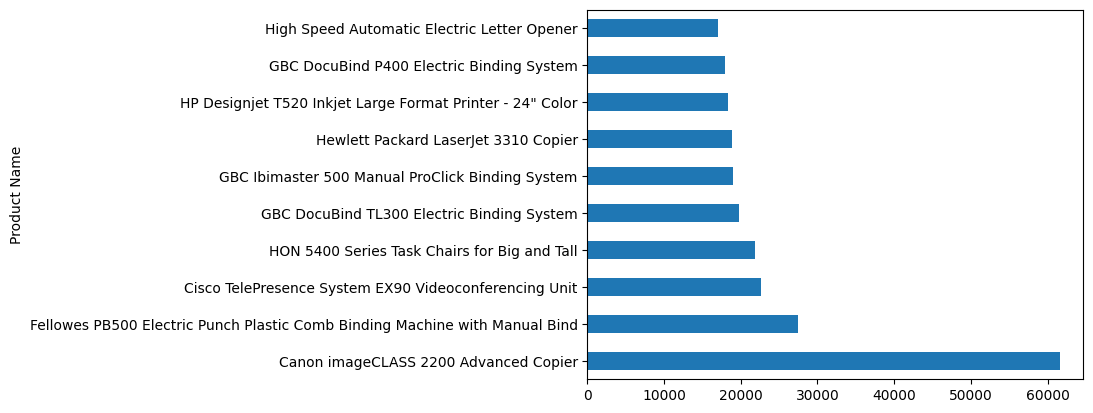

In [30]:
top_products.plot(kind='barh')
plt.show()

### Monthly Sales Trend + Moving Average

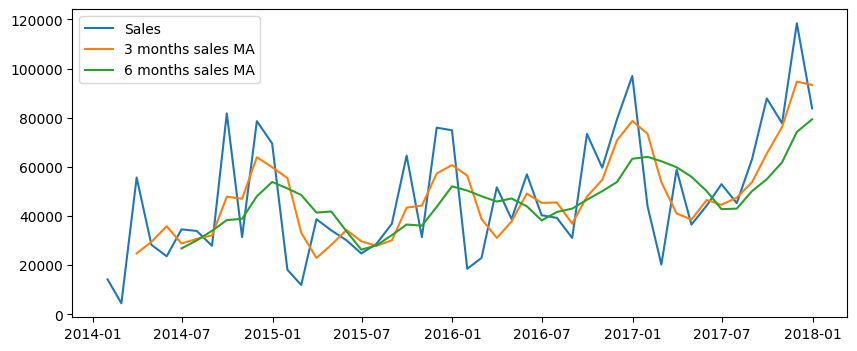

In [31]:
plt.figure(figsize=(10,4))
plt.plot(monthly_sales['Sales'], label='Sales')
plt.plot(monthly_sales['Sales_MA_3'], label='3 months sales MA')
plt.plot(monthly_sales['Sales_MA_6'], label='6 months sales MA')
plt.legend()
plt.show()

### Profit vs Discount
- After discount = 0.3 (30%), the profits are negligible.

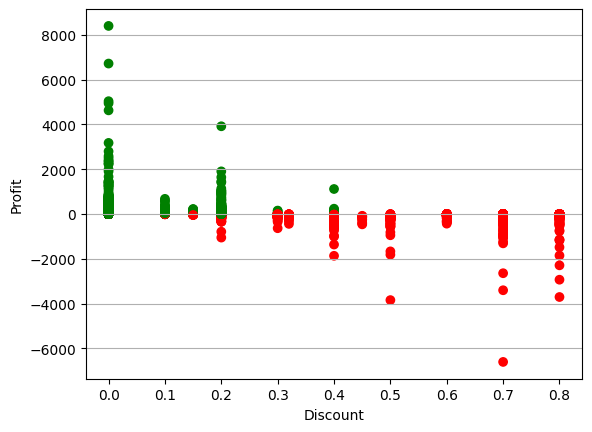

In [32]:
colors = (df["Profit"] > 0).map({True: 'green', False: 'red'}) # pandas Series

plt.scatter(df["Discount"], df["Profit"], c=colors)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(axis='y')
plt.show()

### Profit vs Sales

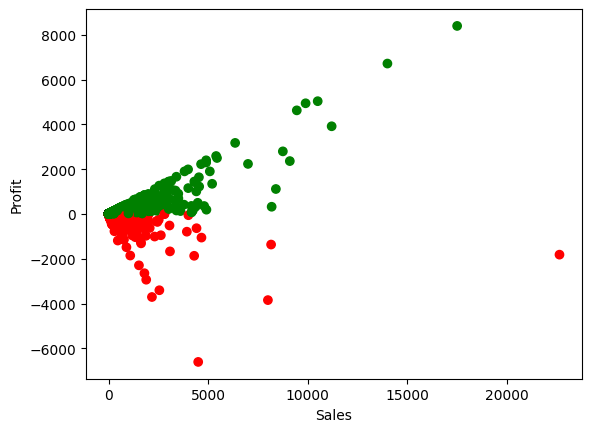

In [33]:
plt.scatter(df["Sales"], df["Profit"], c=colors)
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

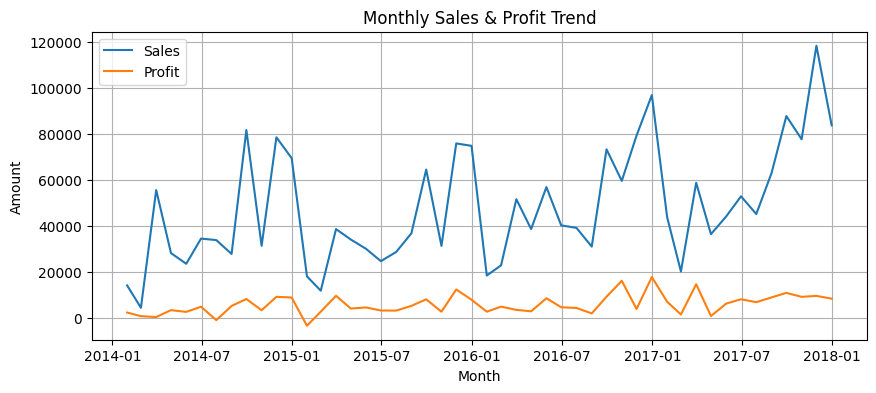

In [34]:
plt.figure(figsize=(10,4))
plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Sales')
plt.plot(monthly_sales.index, monthly_sales['Profit'], label='Profit')

plt.title('Monthly Sales & Profit Trend')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.grid()
plt.show()

### Clustered bar graph for **Sales and Profit** over the years

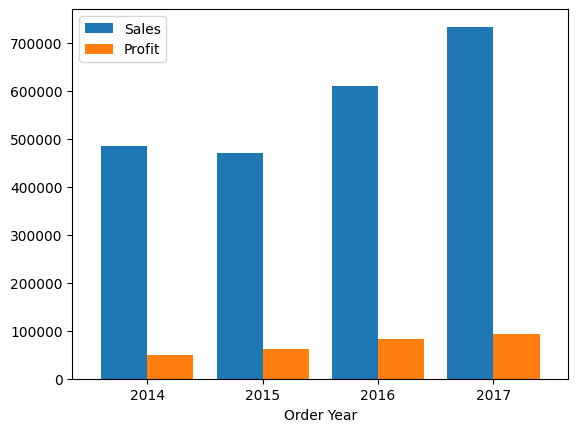

In [35]:
yearly_sales.plot(kind='bar',width=0.8)
plt.plot(yearly_sales['Profit'])
# yearly_sales['Profit'].plot(kind='line')
plt.xticks(rotation=0)
plt.show()

### Profit margin by category

In [36]:
# color scheme
category_colors = {
    'Furniture': 'skyblue',
    'Office Supplies': 'orange',
    'Technology': 'green'
}

cat_colors = cat_sales['Category'].map(category_colors)
sub_cat_colors = sub_cat_sales['Category'].map(category_colors)

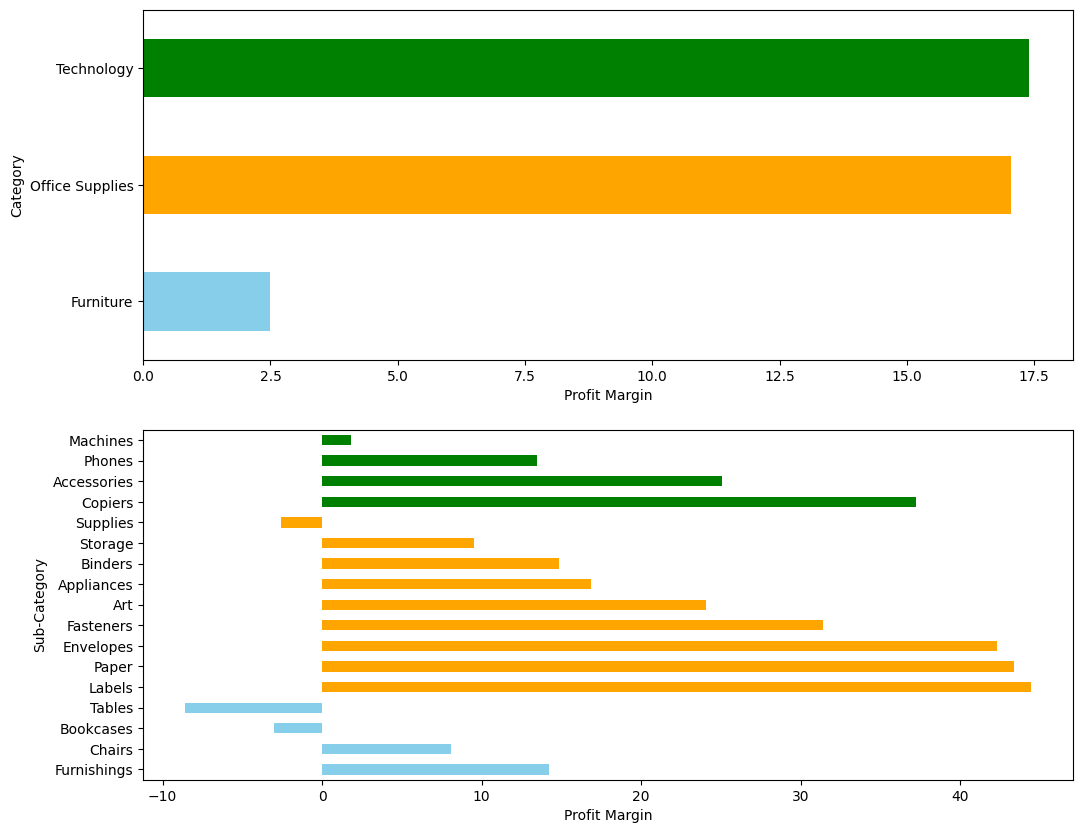

In [37]:
fig, axs = plt.subplots(2,1,figsize=(12,10))
cat_sales.plot(
    kind='barh',
    x='Category',
    y='Profit_Margin',
    color=cat_colors,
    ax=axs[0],
    legend=False,
    xlabel='Profit Margin'
)
sub_cat_sales.plot(
    kind='barh',
    x='Sub-Category',
    y='Profit_Margin',
    color=sub_cat_colors,
    ax=axs[1],
    legend=False,
    xlabel='Profit Margin'
)
# plt.tight_layout()
plt.show()

## TO DO
- Region Performance (Stacked Bar): Sales vs Profit per region
- write insights in a notebook.
- Build Streamlit dashboard UI structure.
- starts working on a Sales prediction model